In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Style setting
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

In [3]:
# Load data
real = pd.read_csv("/content/naterida_clean_data.csv")
synthetic = pd.read_csv("/content/naterida_synthetic_data.csv")
df = pd.concat([real, synthetic], ignore_index=True)

In [4]:
print("NATERIDA ADVANCED ML ANALYSIS")
print(f"\nDataset Shape: {df.shape}")
print(f"Real Data: {len(real)} samples")
print(f"Synthetic Data: {len(synthetic)} samples")

NATERIDA ADVANCED ML ANALYSIS

Dataset Shape: (1346, 5)
Real Data: 346 samples
Synthetic Data: 1000 samples


# Feature Engineering

In [5]:
print("FEATURE ENGINEERING")

# Make a copy to preserve original data
df_engineered = df.copy()

# A) Rolling Averages (for numerical columns)
numerical_cols = df_engineered.select_dtypes(include=[np.number]).columns
numerical_cols = [col for col in numerical_cols if col not in ['GAS VALUE', 'TIMESTAMP']]

for col in numerical_cols:
    # 5-point rolling average
    df_engineered[f'{col}_rolling_5'] = df_engineered[col].rolling(window=5, min_periods=1).mean()
    # 10-point rolling average
    df_engineered[f'{col}_rolling_10'] = df_engineered[col].rolling(window=10, min_periods=1).mean()
    print(f"Created rolling averages for {col}")

# B) Rate of Change (first derivative)
for col in numerical_cols:
    df_engineered[f'{col}_change'] = df_engineered[col].diff().fillna(0)
    # Rate of change percentage
    df_engineered[f'{col}_pct_change'] = df_engineered[col].pct_change().fillna(0).replace([np.inf, -np.inf], 0)
    print(f"Created rate of change for {col}")

# C) Interaction Terms (multiply features together)
# Create interactions between all pairs of numerical features
from itertools import combinations

if len(numerical_cols) >= 2:
    # Limit to top 3-4 features to avoid explosion
    top_features = numerical_cols[:min(4, len(numerical_cols))]

    for feat1, feat2 in combinations(top_features, 2):
        # Multiplication interaction
        df_engineered[f'{feat1}_x_{feat2}'] = df_engineered[feat1] * df_engineered[feat2]
        # Division interaction (avoid division by zero)
        df_engineered[f'{feat1}_div_{feat2}'] = df_engineered[feat1] / (df_engineered[feat2] + 1e-10)
        print(f"✓ Created interaction: {feat1} × {feat2}")

# D) Lag Features (previous values)
df_engineered['GAS_VALUE_lag_1'] = df_engineered['GAS VALUE'].shift(1).fillna(df_engineered['GAS VALUE'].mean())
df_engineered['GAS_VALUE_lag_3'] = df_engineered['GAS VALUE'].shift(3).fillna(df_engineered['GAS VALUE'].mean())
df_engineered['GAS_VALUE_lag_5'] = df_engineered['GAS VALUE'].shift(5).fillna(df_engineered['GAS VALUE'].mean())
print("✓ Created lag features for GAS VALUE")

# E) Statistical Features (if you have enough data points)
window_size = 10
for col in numerical_cols:
    df_engineered[f'{col}_rolling_std'] = df_engineered[col].rolling(window=window_size, min_periods=1).std().fillna(0)
    df_engineered[f'{col}_rolling_min'] = df_engineered[col].rolling(window=window_size, min_periods=1).min()
    df_engineered[f'{col}_rolling_max'] = df_engineered[col].rolling(window=window_size, min_periods=1).max()
    print(f"Created statistical features for {col}")

print(f"\nOriginal features: {len(df.columns)}")
print(f"Engineered features: {len(df_engineered.columns)}")
print(f"New features added: {len(df_engineered.columns) - len(df.columns)}")

# Now use df_engineered instead of df for training
df = df_engineered

FEATURE ENGINEERING
Created rolling averages for LIGHT INTENSITY
Created rolling averages for HUMIDITY
Created rolling averages for TEMPERATURE
Created rate of change for LIGHT INTENSITY
Created rate of change for HUMIDITY
Created rate of change for TEMPERATURE
✓ Created interaction: LIGHT INTENSITY × HUMIDITY
✓ Created interaction: LIGHT INTENSITY × TEMPERATURE
✓ Created interaction: HUMIDITY × TEMPERATURE
✓ Created lag features for GAS VALUE
Created statistical features for LIGHT INTENSITY
Created statistical features for HUMIDITY
Created statistical features for TEMPERATURE

Original features: 5
Engineered features: 35
New features added: 30


In [6]:
X = df.drop(columns=["GAS VALUE", "TIMESTAMP"])
y = df["GAS VALUE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Basic ML baseline

In [7]:
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
print("TRAINING MODEL...")
model.fit(X_train, y_train)

TRAINING MODEL...


RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=500, n_jobs=-1, random_state=42)

In [8]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f"\nCross-Validation R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-Validation R² Scores: [0.13741272 0.21863528 0.17354924 0.27158085 0.14816152]
Mean CV R²: 0.1899 (+/- 0.0990)


In [9]:
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [10]:
r2_test = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("MODEL PERFORMANCE METRICS")
print(f"Test R² Score: {r2_test:.4f}")
print(f"Train R² Score: {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

MODEL PERFORMANCE METRICS
Test R² Score: 0.1891
Train R² Score: 0.8428
MAE: 21.8918
RMSE: 29.6285
MAPE: 2.22%


In [11]:
joblib.dump(model, "naterida_gas_prediction_model_advanced.pkl")
print("\n Model saved as 'naterida_gas_prediction_model_advanced.pkl'")


 Model saved as 'naterida_gas_prediction_model_advanced.pkl'


# Anomaly Detection

In [12]:
# Standardize features for anomaly detection
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
# Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomalies_iso = iso_forest.fit_predict(X_scaled)
n_anomalies = (anomalies_iso == -1).sum()

In [14]:
print(f"\nIsolation Forest detected {n_anomalies} anomalies ({n_anomalies/len(df)*100:.2f}%)")


Isolation Forest detected 68 anomalies (5.05%)


In [15]:
# Statistical anomaly detection (Z-score)
z_scores = np.abs(stats.zscore(df['GAS VALUE']))
anomalies_zscore = z_scores > 3
n_anomalies_z = anomalies_zscore.sum()

print(f"Z-score method detected {n_anomalies_z} anomalies ({n_anomalies_z/len(df)*100:.2f}%)")

df['anomaly_iso'] = anomalies_iso
df['anomaly_zscore'] = anomalies_zscore

Z-score method detected 4 anomalies (0.30%)


# Clustering Analysis

In [16]:
# K-Means Clustering
optimal_k = 4  # You can use elbow method to find this
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print(f"\nK-Means: {optimal_k} clusters created")
for i in range(optimal_k):
    cluster_size = (df['cluster_kmeans'] == i).sum()
    print(f"  Cluster {i}: {cluster_size} samples ({cluster_size/len(df)*100:.1f}%)")


K-Means: 4 clusters created
  Cluster 0: 519 samples (38.6%)
  Cluster 1: 160 samples (11.9%)
  Cluster 2: 174 samples (12.9%)
  Cluster 3: 493 samples (36.6%)


In [17]:
# DBSCAN for density-based clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)
n_clusters_dbscan = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'] else 0)
n_noise = list(df['cluster_dbscan']).count(-1)

print(f"\nDBSCAN: {n_clusters_dbscan} clusters found")
print(f"  Noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")


DBSCAN: 14 clusters found
  Noise points: 1177 (87.4%)


# Advanced Visualizations

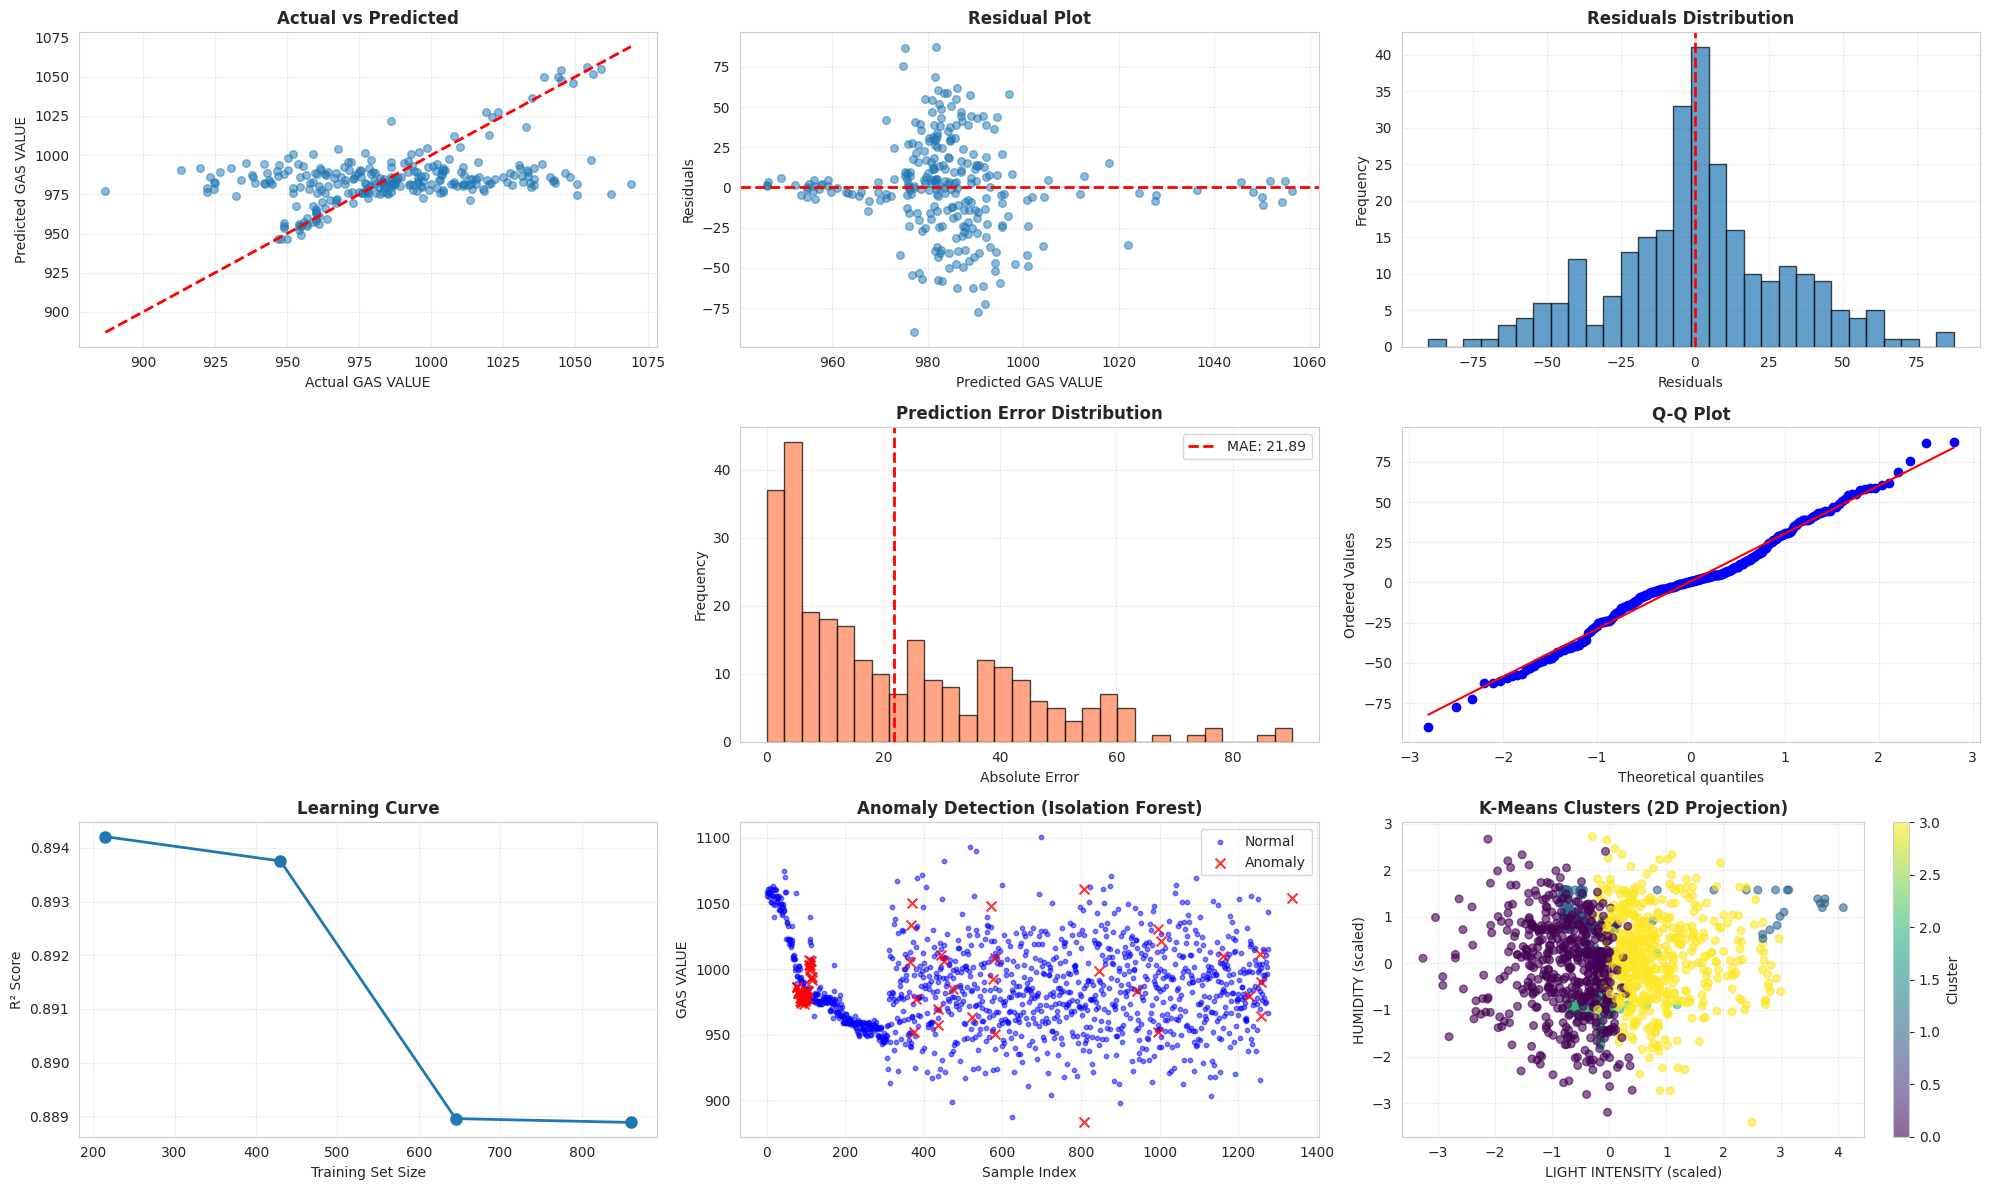

In [19]:
# Figure 1: Comprehensive Performance Dashboard
fig1 = plt.figure(figsize=(20, 12))

# 1.1 Actual vs Predicted with confidence bands
ax1 = plt.subplot(3, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.5, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual GAS VALUE', fontsize=10)
plt.ylabel('Predicted GAS VALUE', fontsize=10)
plt.title('Actual vs Predicted', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 1.2 Residuals Plot
ax2 = plt.subplot(3, 3, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5, s=30)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted GAS VALUE', fontsize=10)
plt.ylabel('Residuals', fontsize=10)
plt.title('Residual Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 1.3 Residuals Distribution
ax3 = plt.subplot(3, 3, 3)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.xlabel('Residuals', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Residuals Distribution', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 1.5 Prediction Error Distribution
ax5 = plt.subplot(3, 3, 5)
errors = np.abs(y_test - y_pred)
plt.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
plt.axvline(x=mae, color='r', linestyle='--', lw=2, label=f'MAE: {mae:.2f}')
plt.xlabel('Absolute Error', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Prediction Error Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 1.6 Q-Q Plot for normality check
ax6 = plt.subplot(3, 3, 6)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 1.7 Learning Curve (simplified)
ax7 = plt.subplot(3, 3, 7)
train_sizes = [0.2, 0.4, 0.6, 0.8] # Removed 1.0 to avoid InvalidParameterError
train_scores = []
for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=size, random_state=42)
    model_temp = RandomForestRegressor(n_estimators=100, random_state=42)
    model_temp.fit(X_sub, y_sub)
    score = model_temp.score(X_sub, y_sub)
    train_scores.append(score)
plt.plot([int(s*len(X_train)) for s in train_sizes], train_scores, 'o-', linewidth=2, markersize=8)
plt.xlabel('Training Set Size', fontsize=10)
plt.ylabel('R² Score', fontsize=10)
plt.title('Learning Curve', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# 1.8 Anomaly Detection Visualization
ax8 = plt.subplot(3, 3, 8)
normal_mask = df['anomaly_iso'] == 1
anomaly_mask = df['anomaly_iso'] == -1
plt.scatter(range(len(df[normal_mask])), df[normal_mask]['GAS VALUE'],
           alpha=0.5, s=10, label='Normal', c='blue')
anomaly_indices = df[anomaly_mask].index
plt.scatter(anomaly_indices, df[anomaly_mask]['GAS VALUE'],
           alpha=0.8, s=50, label='Anomaly', c='red', marker='x')
plt.xlabel('Sample Index', fontsize=10)
plt.ylabel('GAS VALUE', fontsize=10)
plt.title('Anomaly Detection (Isolation Forest)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 1.9 Cluster Visualization (2D projection using first 2 features)
ax9 = plt.subplot(3, 3, 9)
if X.shape[1] >= 2:
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
                         c=df['cluster_kmeans'], cmap='viridis', alpha=0.6, s=30)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel(f'{X.columns[0]} (scaled)', fontsize=10)
    plt.ylabel(f'{X.columns[1]} (scaled)', fontsize=10)
    plt.title('K-Means Clusters (2D Projection)', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('naterida_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

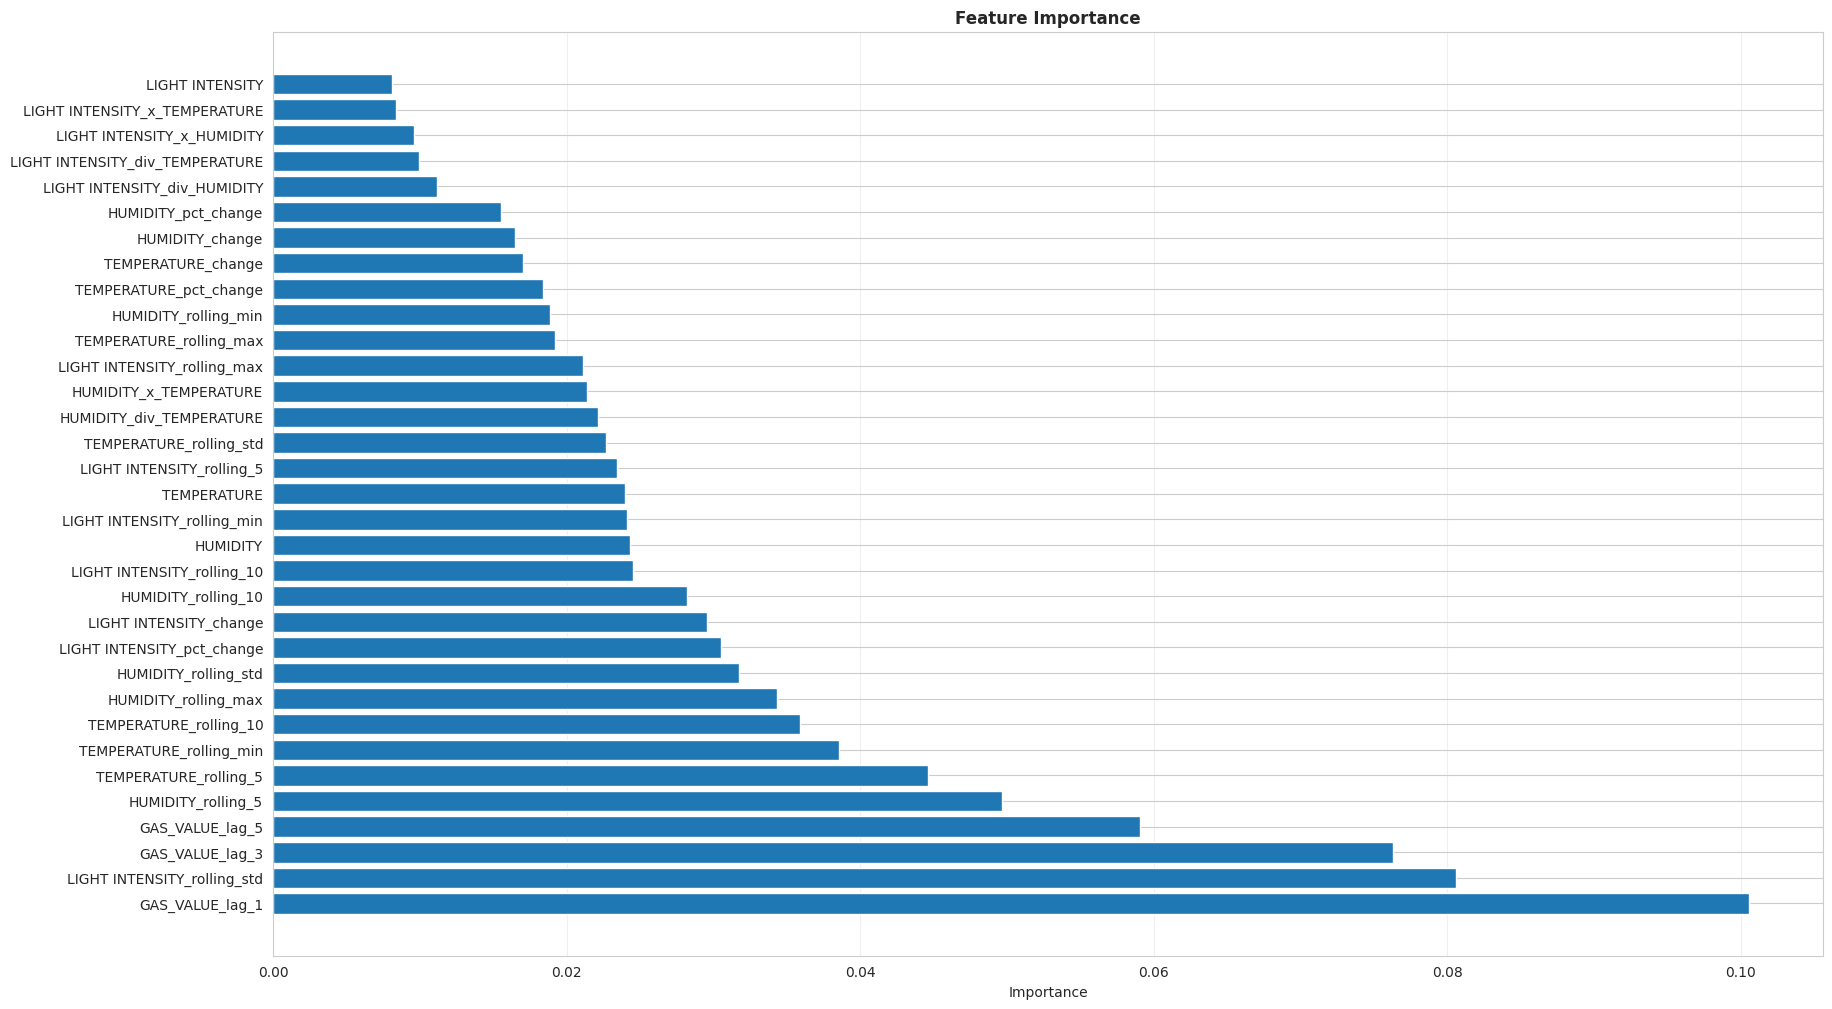

In [20]:
# 1.4 Feature Importance
fig1 = plt.figure(figsize=(20, 12))
ax4 = plt.subplot(1, 1, 1)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), [X.columns[i] for i in indices])
plt.xlabel('Importance', fontsize=10)
plt.title('Feature Importance', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

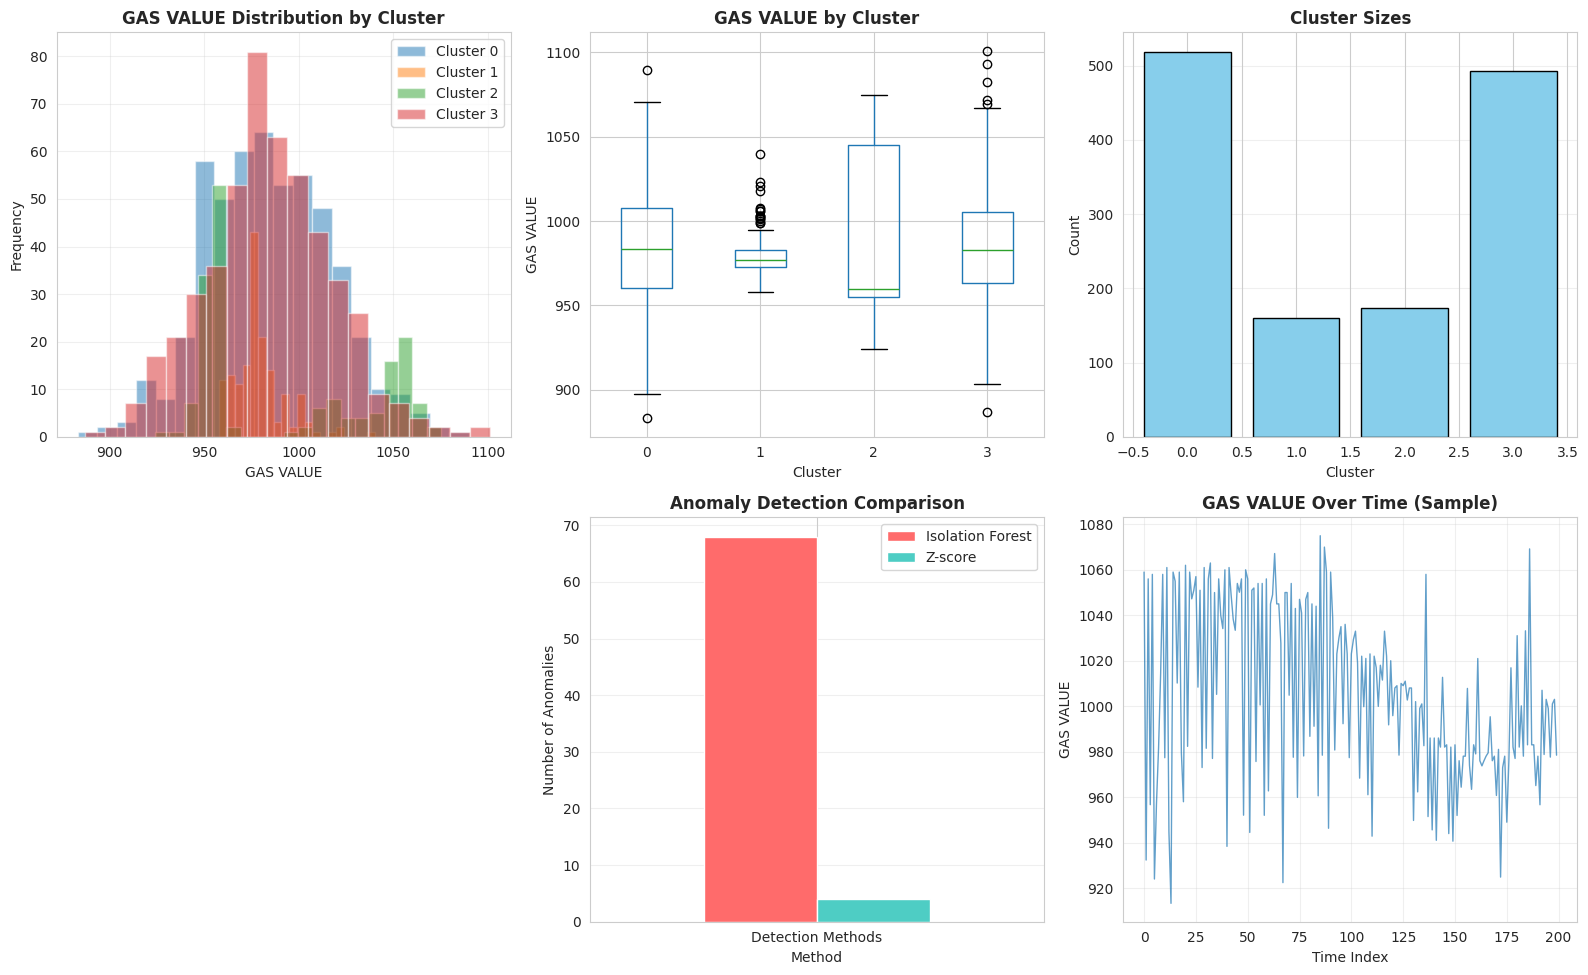

✓ Cluster analysis saved as 'naterida_cluster_analysis.png'


In [21]:
# Figure 2: Cluster Analysis Deep Dive
fig2 = plt.figure(figsize=(16, 10))

# 2.1 Cluster-wise GAS VALUE Distribution
ax1 = plt.subplot(2, 3, 1)
for i in range(optimal_k):
    cluster_data = df[df['cluster_kmeans'] == i]['GAS VALUE']
    plt.hist(cluster_data, alpha=0.5, label=f'Cluster {i}', bins=20)
plt.xlabel('GAS VALUE', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('GAS VALUE Distribution by Cluster', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 2.2 Box plot of GAS VALUE by cluster
ax2 = plt.subplot(2, 3, 2)
df.boxplot(column='GAS VALUE', by='cluster_kmeans', ax=ax2)
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('GAS VALUE', fontsize=10)
plt.title('GAS VALUE by Cluster', fontsize=12, fontweight='bold')
plt.suptitle('')

# 2.3 Cluster sizes
ax3 = plt.subplot(2, 3, 3)
cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color='skyblue', edgecolor='black')
plt.xlabel('Cluster', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.title('Cluster Sizes', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

# 2.5 Anomaly comparison
ax5 = plt.subplot(2, 3, 5)
anomaly_comparison = pd.DataFrame({
    'Isolation Forest': [n_anomalies],
    'Z-score': [n_anomalies_z]
})
anomaly_comparison.plot(kind='bar', ax=ax5, color=['#ff6b6b', '#4ecdc4'])
plt.xlabel('Method', fontsize=10)
plt.ylabel('Number of Anomalies', fontsize=10)
plt.title('Anomaly Detection Comparison', fontsize=12, fontweight='bold')
plt.xticks([0], ['Detection Methods'], rotation=0)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 2.6 Time series view (if timestamp available)
ax6 = plt.subplot(2, 3, 6)
if 'TIMESTAMP' in df.columns:
    try:
        df_sorted = df.sort_values('TIMESTAMP').head(200)
        plt.plot(range(len(df_sorted)), df_sorted['GAS VALUE'], alpha=0.7, linewidth=1)
        plt.xlabel('Time Index', fontsize=10)
        plt.ylabel('GAS VALUE', fontsize=10)
        plt.title('GAS VALUE Over Time (Sample)', fontsize=12, fontweight='bold')
        plt.grid(True, alpha=0.3)
    except:
        plt.text(0.5, 0.5, 'Timestamp visualization unavailable',
                ha='center', va='center', transform=ax6.transAxes)
else:
    plt.text(0.5, 0.5, 'No timestamp data',
            ha='center', va='center', transform=ax6.transAxes)

plt.tight_layout()
plt.savefig('naterida_cluster_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cluster analysis saved as 'naterida_cluster_analysis.png'")


Text(0.5, 1.0, 'Feature Correlation Matrix')

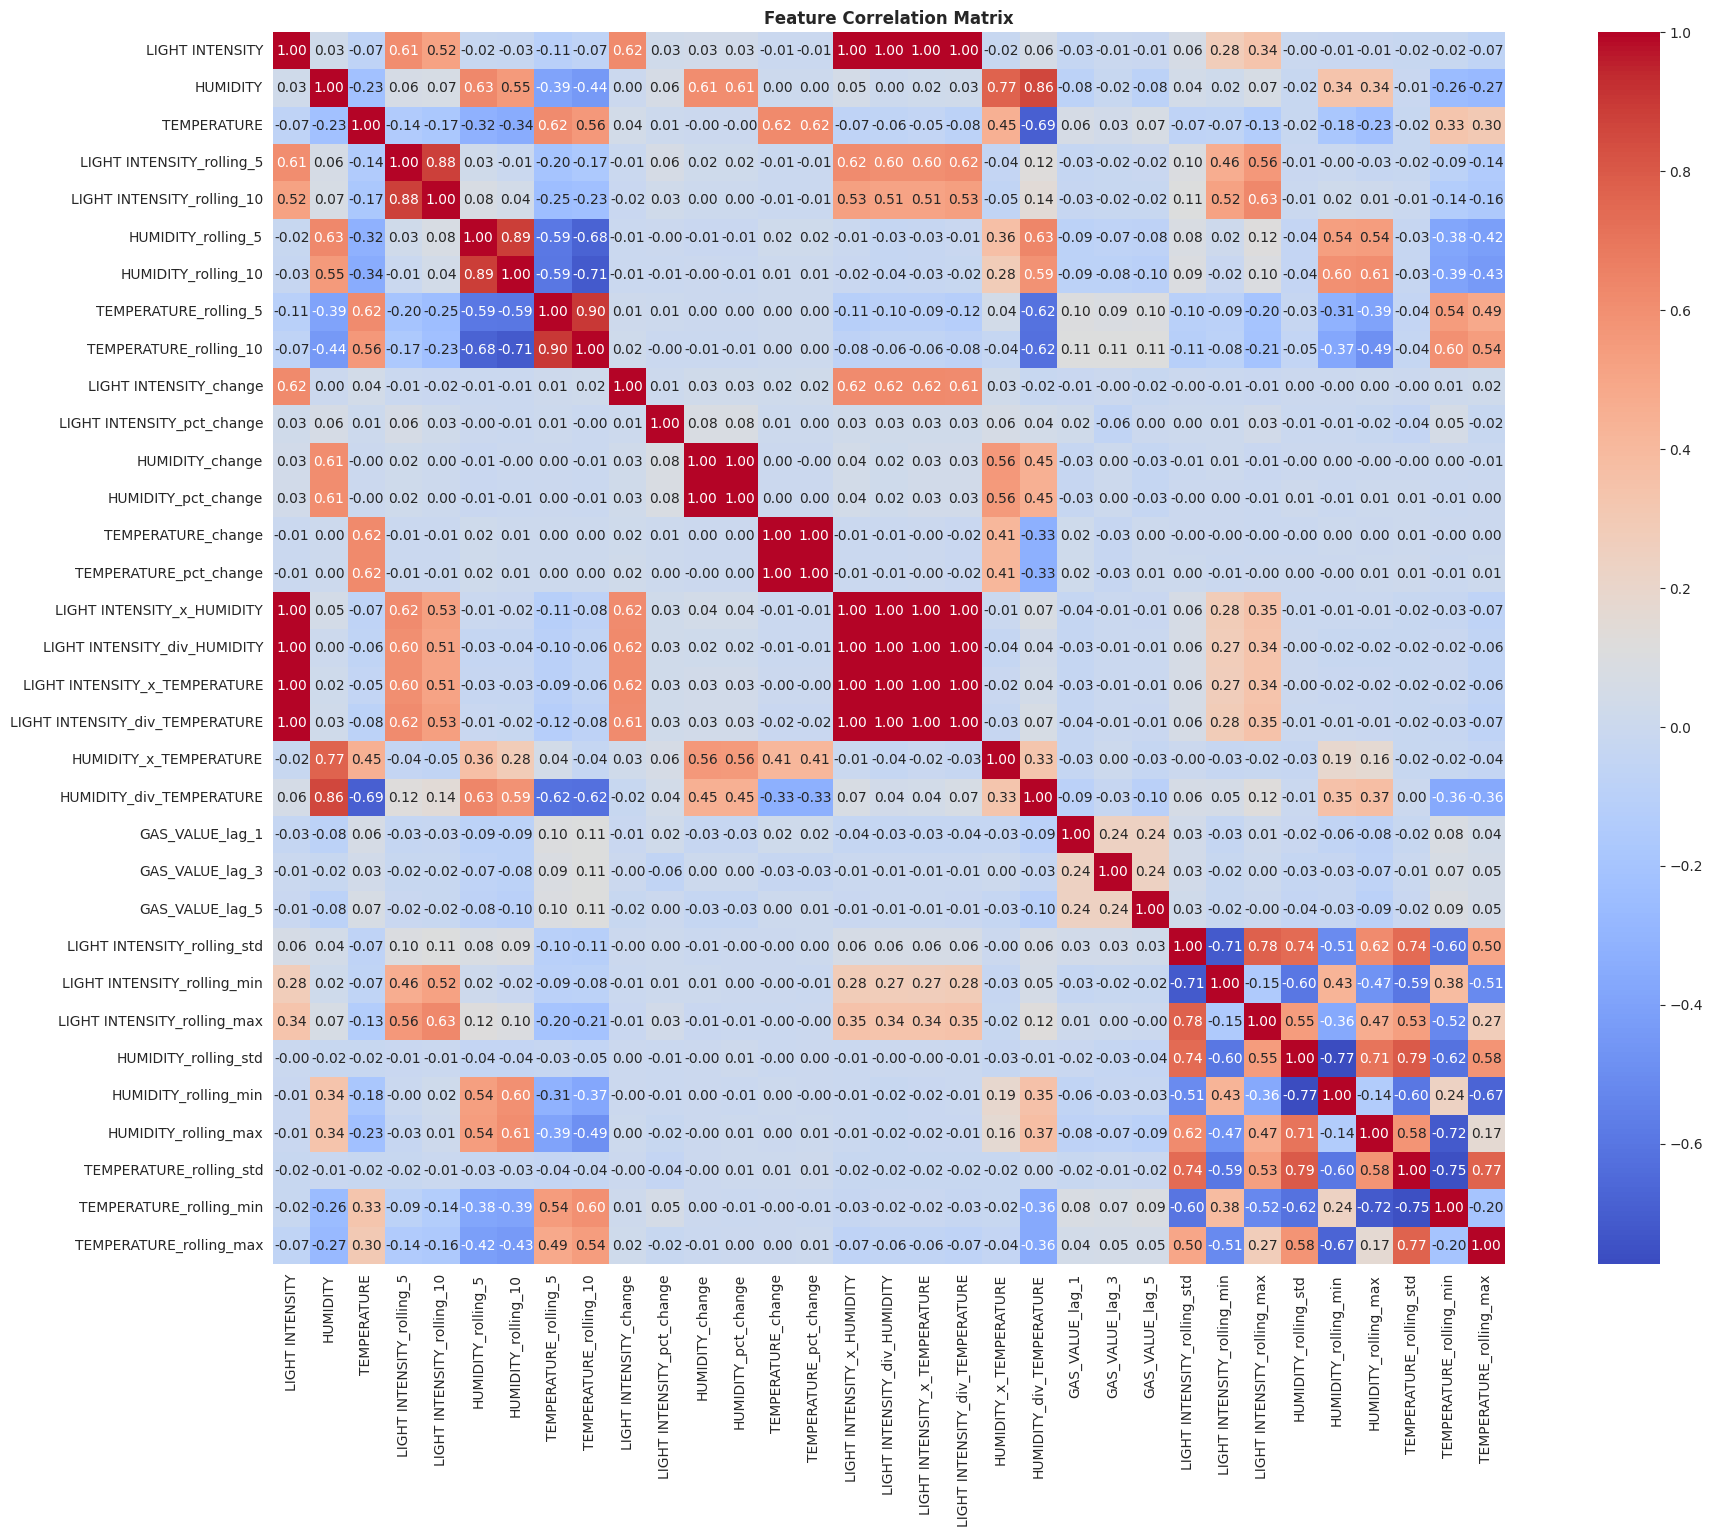

In [22]:
# 2.4 Feature correlation heatmap
fig1 = plt.figure(figsize=(24, 16))
ax4 = plt.subplot(1, 1, 1)
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax4, square=True)
plt.title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 3D cluster visualization


3D CLUSTER VISUALIZATION (PCA)

Original dimensions: 37
Reduced to: 3 dimensions
Variance explained by 3 components: 51.04%
  - PC1: 19.51%
  - PC2: 16.55%
  - PC3: 14.98%


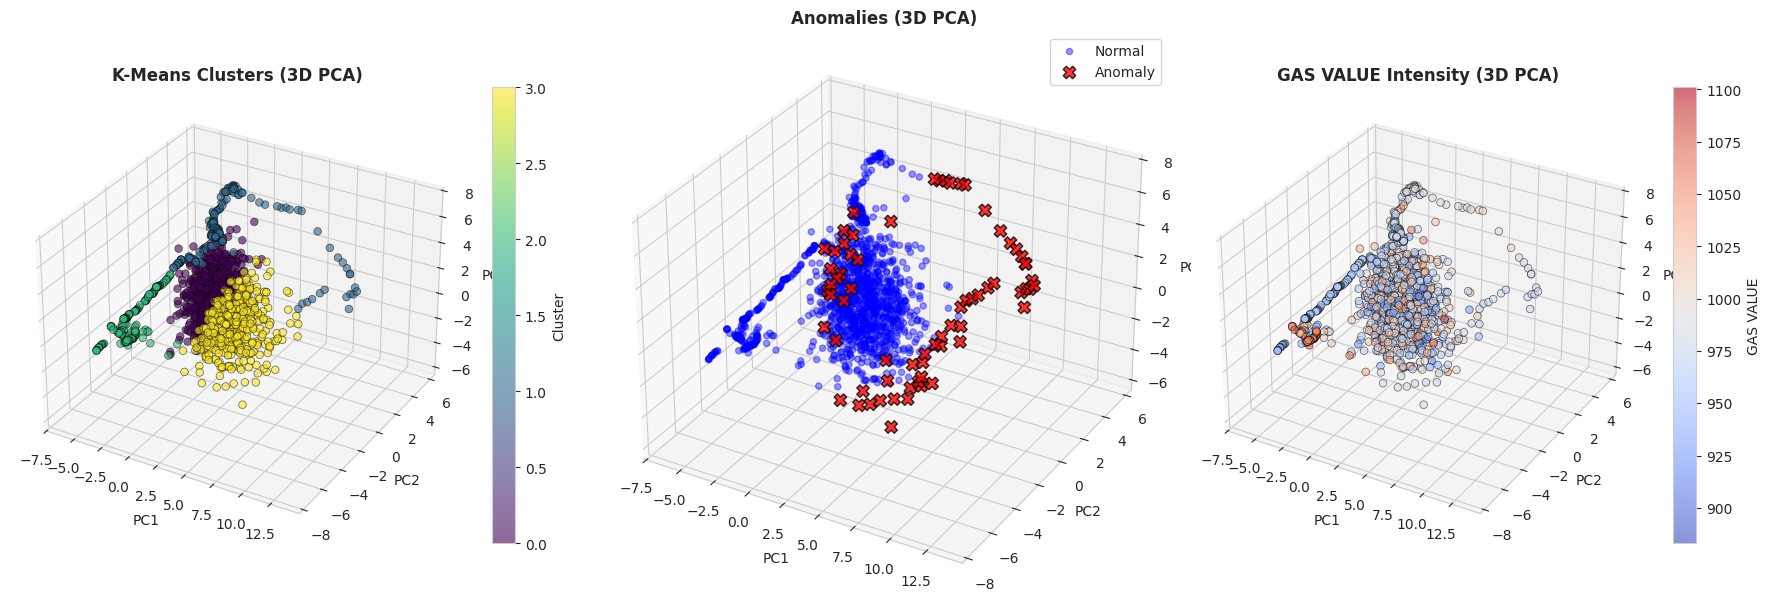


✓ 3D PCA visualization saved as 'naterida_3d_pca_visualization.png'

TOP CONTRIBUTING FEATURES TO PRINCIPAL COMPONENTS

PC1 (explains 19.51% variance):
  - LIGHT INTENSITY_x_HUMIDITY: 0.332
  - LIGHT INTENSITY_div_TEMPERATURE: 0.332
  - LIGHT INTENSITY: 0.330
  - LIGHT INTENSITY_x_TEMPERATURE: 0.328
  - LIGHT INTENSITY_div_HUMIDITY: 0.327

PC2 (explains 16.55% variance):
  - HUMIDITY_rolling_max: 0.327
  - TEMPERATURE_rolling_min: 0.315
  - TEMPERATURE_rolling_10: 0.244
  - HUMIDITY_rolling_10: 0.243
  - HUMIDITY_rolling_5: 0.239

PC3 (explains 14.98% variance):
  - HUMIDITY_rolling_min: 0.361
  - TEMPERATURE_rolling_max: 0.353
  - HUMIDITY_rolling_std: 0.307
  - TEMPERATURE_rolling_std: 0.305
  - LIGHT INTENSITY_rolling_std: 0.277


In [23]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

print("\n" + "="*60)
print("3D CLUSTER VISUALIZATION (PCA)")
print("="*60)

# Prepare data for PCA
X_for_pca = df.drop(columns=["GAS VALUE", "TIMESTAMP"], errors='ignore')

# Handle any remaining NaN or inf values
X_for_pca = X_for_pca.replace([np.inf, -np.inf], np.nan)
X_for_pca = X_for_pca.fillna(X_for_pca.mean())

# Standardize features for PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_for_pca)

# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_pca)

print(f"\nOriginal dimensions: {X_for_pca.shape[1]}")
print(f"Reduced to: 3 dimensions")
print(f"Variance explained by 3 components: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  - PC3: {pca.explained_variance_ratio_[2]:.2%}")

# Create 3D visualization
fig = plt.figure(figsize=(18, 6))

# Plot 1: K-Means Clusters in 3D
ax1 = fig.add_subplot(131, projection='3d')
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                       c=df['cluster_kmeans'], cmap='viridis',
                       s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
ax1.set_xlabel('PC1', fontsize=10)
ax1.set_ylabel('PC2', fontsize=10)
ax1.set_zlabel('PC3', fontsize=10)
ax1.set_title('K-Means Clusters (3D PCA)', fontsize=12, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='Cluster', shrink=0.8)

# Plot 2: Anomalies in 3D
ax2 = fig.add_subplot(132, projection='3d')
normal_mask = df['anomaly_iso'] == 1
anomaly_mask = df['anomaly_iso'] == -1
ax2.scatter(X_pca[normal_mask, 0], X_pca[normal_mask, 1], X_pca[normal_mask, 2],
           c='blue', s=20, alpha=0.4, label='Normal')
ax2.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], X_pca[anomaly_mask, 2],
           c='red', s=80, alpha=0.8, marker='X', label='Anomaly', edgecolors='black')
ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)
ax2.set_zlabel('PC3', fontsize=10)
ax2.set_title('Anomalies (3D PCA)', fontsize=12, fontweight='bold')
ax2.legend()

# Plot 3: Gas Value intensity in 3D
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                      c=df['GAS VALUE'], cmap='coolwarm',
                      s=30, alpha=0.6, edgecolors='k', linewidth=0.5)
ax3.set_xlabel('PC1', fontsize=10)
ax3.set_ylabel('PC2', fontsize=10)
ax3.set_zlabel('PC3', fontsize=10)
ax3.set_title('GAS VALUE Intensity (3D PCA)', fontsize=12, fontweight='bold')
plt.colorbar(scatter3, ax=ax3, label='GAS VALUE', shrink=0.8)

plt.tight_layout()
plt.savefig('naterida_3d_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ 3D PCA visualization saved as 'naterida_3d_pca_visualization.png'")

# BONUS: Show which original features contribute most to each PC
print("\n" + "="*60)
print("TOP CONTRIBUTING FEATURES TO PRINCIPAL COMPONENTS")
print("="*60)

feature_names = X_for_pca.columns
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=['PC1', 'PC2', 'PC3']
)

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    print(f"\n{pc} (explains {pca.explained_variance_ratio_[i]:.2%} variance):")
    top_features = components_df.loc[pc].abs().nlargest(5)
    for feat, val in top_features.items():
        print(f"  - {feat}: {val:.3f}")

# Export Results

In [24]:
results_df = df.copy()
results_df['predicted_gas_value'] = model.predict(X)
results_df['prediction_error'] = results_df['GAS VALUE'] - results_df['predicted_gas_value']
results_df.to_csv('naterida_results_with_predictions.csv', index=False)

print("\n✓ Results exported to 'naterida_results_with_predictions.csv'")


✓ Results exported to 'naterida_results_with_predictions.csv'


In [25]:
# Summary Report

print("SUMMARY REPORT")
print(f"Model Accuracy (R²): {r2_test:.4f}")
print(f"Prediction Error (MAPE): {mape:.2f}%")
print(f"Anomalies Detected: {n_anomalies} samples")
print(f"Clusters Identified: {optimal_k}")
print(f"Most Important Feature: {X.columns[indices[0]]}")


SUMMARY REPORT
Model Accuracy (R²): 0.1891
Prediction Error (MAPE): 2.22%
Anomalies Detected: 68 samples
Clusters Identified: 4
Most Important Feature: GAS_VALUE_lag_1


# Alert System

In [26]:
import warnings
from datetime import datetime

print("INTELLIGENT ALERT SYSTEM")

class NateridaAlertSystem:
    def __init__(self, df, model, threshold_config=None):
        self.df = df
        self.model = model
        self.alerts = []

        # Default thresholds (adjust based on your data)
        if threshold_config is None:
            self.threshold_config = {
                'gas_critical': df['GAS VALUE'].quantile(0.95),  # Top 5%
                'gas_warning': df['GAS VALUE'].quantile(0.85),   # Top 15%
                'prediction_error_high': 50,  # High prediction error
                'rapid_change_threshold': df['GAS VALUE'].std() * 2,  # 2 std devs
            }
        else:
            self.threshold_config = threshold_config

    def check_gas_level_alerts(self):
        """Check for dangerous gas levels"""
        critical_mask = self.df['GAS VALUE'] > self.threshold_config['gas_critical']
        warning_mask = (self.df['GAS VALUE'] > self.threshold_config['gas_warning']) & ~critical_mask

        n_critical = critical_mask.sum()
        n_warning = warning_mask.sum()

        if n_critical > 0:
            self.alerts.append({
                'type': 'CRITICAL',
                'category': 'Gas Level',
                'message': f'⛔ CRITICAL: {n_critical} readings exceed safe gas levels!',
                'severity': 3,
                'count': n_critical,
                'threshold': self.threshold_config['gas_critical']
            })

        if n_warning > 0:
            self.alerts.append({
                'type': 'WARNING',
                'category': 'Gas Level',
                'message': f'⚠️  WARNING: {n_warning} readings show elevated gas levels',
                'severity': 2,
                'count': n_warning,
                'threshold': self.threshold_config['gas_warning']
            })

        return n_critical, n_warning

    def check_anomaly_alerts(self):
        """Check for anomalies detected"""
        if 'anomaly_iso' in self.df.columns:
            anomaly_mask = self.df['anomaly_iso'] == -1
            n_anomalies = anomaly_mask.sum()

            if n_anomalies > 0:
                anomaly_percentage = (n_anomalies / len(self.df)) * 100

                if anomaly_percentage > 10:
                    severity = 3
                    alert_type = 'CRITICAL'
                    icon = '⛔'
                elif anomaly_percentage > 5:
                    severity = 2
                    alert_type = 'WARNING'
                    icon = '⚠️'
                else:
                    severity = 1
                    alert_type = 'INFO'
                    icon = 'ℹ️'

                self.alerts.append({
                    'type': alert_type,
                    'category': 'Anomaly Detection',
                    'message': f'{icon} {alert_type}: {n_anomalies} anomalies detected ({anomaly_percentage:.1f}%)',
                    'severity': severity,
                    'count': n_anomalies
                })

            return n_anomalies
        return 0

    def check_prediction_accuracy_alerts(self, y_test, y_pred):
        """Check for poor prediction accuracy"""
        errors = np.abs(y_test - y_pred)
        high_error_mask = errors > self.threshold_config['prediction_error_high']
        n_high_errors = high_error_mask.sum()

        if n_high_errors > len(y_test) * 0.1:  # More than 10% high errors
            self.alerts.append({
                'type': 'WARNING',
                'category': 'Model Performance',
                'message': f'⚠️  WARNING: {n_high_errors} predictions have high error (>{self.threshold_config["prediction_error_high"]})',
                'severity': 2,
                'count': n_high_errors
            })

        # Check for systematic bias
        mean_error = np.mean(y_test - y_pred)
        if abs(mean_error) > self.threshold_config['prediction_error_high'] * 0.5:
            bias_direction = "overestimating" if mean_error < 0 else "underestimating"
            self.alerts.append({
                'type': 'INFO',
                'category': 'Model Bias',
                'message': f'ℹ️  INFO: Model is {bias_direction} by {abs(mean_error):.2f} on average',
                'severity': 1,
                'bias': mean_error
            })

        return n_high_errors

    def check_rapid_change_alerts(self):
        """Check for rapid changes in gas values"""
        if 'GAS VALUE' in self.df.columns:
            changes = self.df['GAS VALUE'].diff().abs()
            rapid_changes = changes > self.threshold_config['rapid_change_threshold']
            n_rapid = rapid_changes.sum()

            if n_rapid > 0:
                self.alerts.append({
                    'type': 'WARNING',
                    'category': 'Rapid Change',
                    'message': f'⚠️  WARNING: {n_rapid} instances of rapid gas level changes detected',
                    'severity': 2,
                    'count': n_rapid,
                    'max_change': changes.max()
                })

            return n_rapid
        return 0

    def check_cluster_alerts(self):
        """Check for unusual cluster distributions"""
        if 'cluster_kmeans' in self.df.columns:
            cluster_counts = self.df['cluster_kmeans'].value_counts()

            # Check for highly imbalanced clusters
            max_cluster_pct = (cluster_counts.max() / len(self.df)) * 100
            min_cluster_pct = (cluster_counts.min() / len(self.df)) * 100

            if max_cluster_pct > 70:
                self.alerts.append({
                    'type': 'INFO',
                    'category': 'Cluster Distribution',
                    'message': f'ℹ️  INFO: Cluster imbalance detected - one cluster has {max_cluster_pct:.1f}% of data',
                    'severity': 1
                })

            # Check for critical conditions in specific clusters
            for cluster_id in cluster_counts.index:
                cluster_data = self.df[self.df['cluster_kmeans'] == cluster_id]
                cluster_mean_gas = cluster_data['GAS VALUE'].mean()

                if cluster_mean_gas > self.threshold_config['gas_critical']:
                    self.alerts.append({
                        'type': 'CRITICAL',
                        'category': 'Cluster Analysis',
                        'message': f'⛔ CRITICAL: Cluster {cluster_id} has dangerously high average gas level ({cluster_mean_gas:.2f})',
                        'severity': 3,
                        'cluster_id': cluster_id,
                        'cluster_size': len(cluster_data)
                    })

    def generate_alert_report(self):
        """Generate comprehensive alert report"""
        if not self.alerts:
            print("\n✅ ALL SYSTEMS NORMAL - No alerts triggered")
            return

        # Sort alerts by severity (highest first)
        sorted_alerts = sorted(self.alerts, key=lambda x: x['severity'], reverse=True)

        print(f"\n🚨 ALERT SUMMARY: {len(self.alerts)} alert(s) detected\n")

        # Count by severity
        critical_count = sum(1 for a in self.alerts if a['type'] == 'CRITICAL')
        warning_count = sum(1 for a in self.alerts if a['type'] == 'WARNING')
        info_count = sum(1 for a in self.alerts if a['type'] == 'INFO')

        print("━" * 60)
        if critical_count > 0:
            print(f"⛔ CRITICAL ALERTS: {critical_count}")
        if warning_count > 0:
            print(f"⚠️  WARNING ALERTS: {warning_count}")
        if info_count > 0:
            print(f"ℹ️  INFO ALERTS: {info_count}")
        print("━" * 60)

        # Display each alert
        for i, alert in enumerate(sorted_alerts, 1):
            print(f"\n[{i}] {alert['message']}")
            print(f"    Category: {alert['category']}")
            if 'count' in alert:
                print(f"    Affected samples: {alert['count']}")
            if 'threshold' in alert:
                print(f"    Threshold: {alert['threshold']:.2f}")

        print("\n" + "━" * 60)

        # Save alerts to file
        alert_df = pd.DataFrame(sorted_alerts)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        alert_filename = f'naterida_alerts_{timestamp}.csv'
        alert_df.to_csv(alert_filename, index=False)
        print(f"\n✓ Alert report saved to: {alert_filename}")

        return alert_df

    def generate_recommendations(self):
        """Generate actionable recommendations based on alerts"""
        print("\n" + "="*60)
        print("RECOMMENDED ACTIONS")
        print("="*60)

        recommendations = []

        # Check for critical alerts
        critical_alerts = [a for a in self.alerts if a['type'] == 'CRITICAL']
        if critical_alerts:
            recommendations.append("🔴 IMMEDIATE ACTION REQUIRED:")
            for alert in critical_alerts:
                if 'Gas Level' in alert['category']:
                    recommendations.append("   → Evacuate area and investigate gas source")
                    recommendations.append("   → Check ventilation systems")
                elif 'Cluster' in alert['category']:
                    recommendations.append(f"   → Investigate environmental conditions in Cluster {alert.get('cluster_id', 'N/A')}")

        # Check for warning alerts
        warning_alerts = [a for a in self.alerts if a['type'] == 'WARNING']
        if warning_alerts:
            recommendations.append("\n🟡 ATTENTION NEEDED:")
            for alert in warning_alerts:
                if 'Rapid Change' in alert['category']:
                    recommendations.append("   → Monitor gas levels more frequently")
                    recommendations.append("   → Check for leaks or malfunctions")
                elif 'Model Performance' in alert['category']:
                    recommendations.append("   → Review sensor calibration")
                    recommendations.append("   → Consider retraining model with recent data")
                elif 'Anomaly' in alert['category']:
                    recommendations.append("   → Investigate anomalous readings")
                    recommendations.append("   → Verify sensor functionality")

        # General recommendations
        recommendations.append("\n🔵 GENERAL RECOMMENDATIONS:")
        recommendations.append("   → Schedule regular sensor maintenance")
        recommendations.append("   → Update prediction model weekly with new data")
        recommendations.append("   → Document all alert incidents for trend analysis")

        for rec in recommendations:
            print(rec)

INTELLIGENT ALERT SYSTEM


In [27]:
# RUN ALERT SYSTEM

# Initialize alert system
alert_system = NateridaAlertSystem(df, model)

# Run all checks
print("\nRunning comprehensive alert checks...")
alert_system.check_gas_level_alerts()
alert_system.check_anomaly_alerts()
alert_system.check_prediction_accuracy_alerts(y_test, y_pred)
alert_system.check_rapid_change_alerts()
alert_system.check_cluster_alerts()

# Generate reports
alert_report = alert_system.generate_alert_report()
alert_system.generate_recommendations()

print("\n" + "="*60)
print("ALERT SYSTEM CHECK COMPLETE")
print("="*60)



Running comprehensive alert checks...

🚨 ALERT SUMMARY: 5 alert(s) detected

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⛔ CRITICAL ALERTS: 1
⚠️  WARNING ALERTS: 4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[1] ⛔ CRITICAL: 65 readings exceed safe gas levels!
    Category: Gas Level
    Affected samples: 65
    Threshold: 1050.00

[2] ⚠️  WARNING: 137 readings show elevated gas levels
    Category: Gas Level
    Affected samples: 137
    Threshold: 1020.47

[3] ⚠️ WARNING: 68 anomalies detected (5.1%)
    Category: Anomaly Detection
    Affected samples: 68

[4] ⚠️  WARNING: 29 predictions have high error (>50)
    Category: Model Performance
    Affected samples: 29

[5] ⚠️  WARNING: 167 instances of rapid gas level changes detected
    Category: Rapid Change
    Affected samples: 167

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Alert report saved to: naterida_alerts_20251225_022118.csv

RECOMMENDED ACTIONS
🔴 IMMEDIATE ACTION REQ

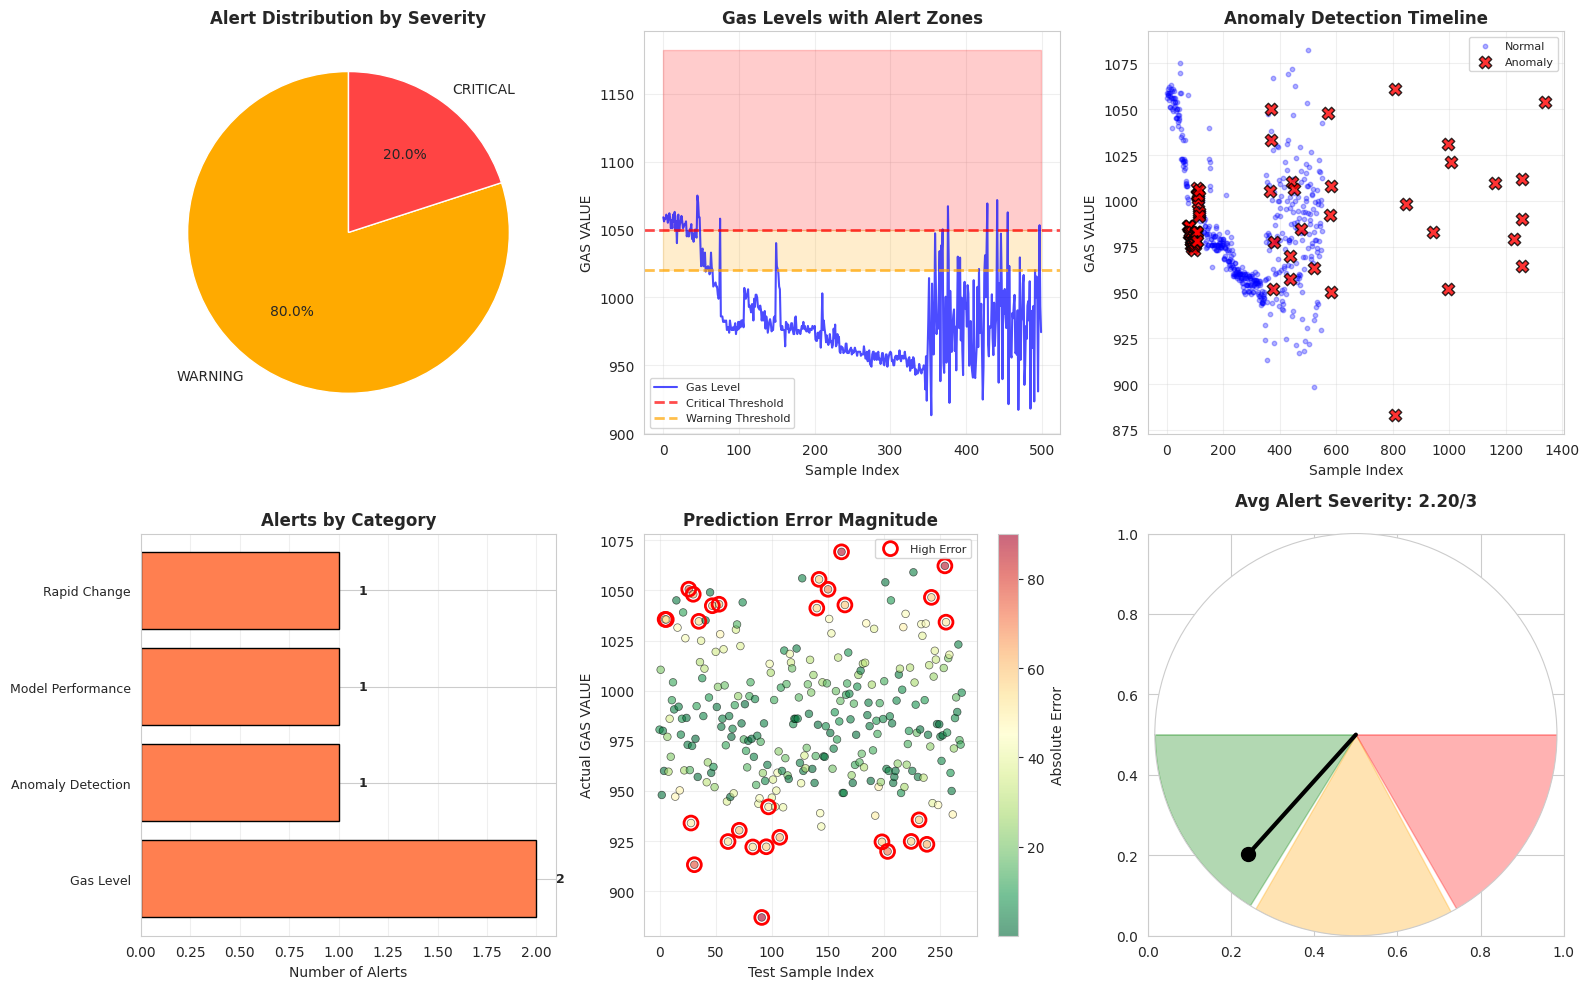


✓ Alert dashboard saved as 'naterida_alert_dashboard.png'


In [28]:
# VISUAL ALERT DASHBOARD

fig = plt.figure(figsize=(16, 10))

# 1. Alert Summary Pie Chart
ax1 = plt.subplot(2, 3, 1)
if alert_system.alerts:
    alert_types = [a['type'] for a in alert_system.alerts]
    type_counts = pd.Series(alert_types).value_counts()
    colors = {'CRITICAL': '#ff4444', 'WARNING': '#ffaa00', 'INFO': '#4444ff'}
    pie_colors = [colors.get(t, '#888888') for t in type_counts.index]

    ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 10})
    ax1.set_title('Alert Distribution by Severity', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, '✅ No Alerts', ha='center', va='center',
             fontsize=20, transform=ax1.transAxes, color='green', fontweight='bold')
    ax1.axis('off')

# 2. Gas Level Over Time with Alert Zones
ax2 = plt.subplot(2, 3, 2)
sample_indices = range(min(500, len(df)))  # Show first 500 samples
gas_values = df['GAS VALUE'].iloc[:500]

ax2.plot(sample_indices, gas_values, linewidth=1.5, alpha=0.7, color='blue', label='Gas Level')
ax2.axhline(y=alert_system.threshold_config['gas_critical'], color='red',
            linestyle='--', linewidth=2, label='Critical Threshold', alpha=0.7)
ax2.axhline(y=alert_system.threshold_config['gas_warning'], color='orange',
            linestyle='--', linewidth=2, label='Warning Threshold', alpha=0.7)
ax2.fill_between(sample_indices, alert_system.threshold_config['gas_critical'],
                  gas_values.max() * 1.1, alpha=0.2, color='red')
ax2.fill_between(sample_indices, alert_system.threshold_config['gas_warning'],
                  alert_system.threshold_config['gas_critical'], alpha=0.2, color='orange')
ax2.set_xlabel('Sample Index', fontsize=10)
ax2.set_ylabel('GAS VALUE', fontsize=10)
ax2.set_title('Gas Levels with Alert Zones', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Anomaly Timeline
ax3 = plt.subplot(2, 3, 3)
if 'anomaly_iso' in df.columns:
    anomaly_indices = df[df['anomaly_iso'] == -1].index[:500]
    normal_indices = df[df['anomaly_iso'] == 1].index[:500]

    ax3.scatter(normal_indices, df.loc[normal_indices, 'GAS VALUE'],
                s=10, alpha=0.3, color='blue', label='Normal')
    ax3.scatter(anomaly_indices, df.loc[anomaly_indices, 'GAS VALUE'],
                s=80, alpha=0.8, color='red', marker='X', label='Anomaly', edgecolors='black')
    ax3.set_xlabel('Sample Index', fontsize=10)
    ax3.set_ylabel('GAS VALUE', fontsize=10)
    ax3.set_title('Anomaly Detection Timeline', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

# 4. Alert Categories Bar Chart
ax4 = plt.subplot(2, 3, 4)
if alert_system.alerts:
    categories = [a['category'] for a in alert_system.alerts]
    category_counts = pd.Series(categories).value_counts()

    bars = ax4.barh(range(len(category_counts)), category_counts.values, color='coral', edgecolor='black')
    ax4.set_yticks(range(len(category_counts)))
    ax4.set_yticklabels(category_counts.index, fontsize=9)
    ax4.set_xlabel('Number of Alerts', fontsize=10)
    ax4.set_title('Alerts by Category', fontsize=12, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, category_counts.values)):
        ax4.text(val + 0.1, i, str(val), va='center', fontsize=9, fontweight='bold')

# 5. Prediction Error Heatmap
ax5 = plt.subplot(2, 3, 5)
errors = np.abs(y_test.values - y_pred)
error_threshold = alert_system.threshold_config['prediction_error_high']
high_error_mask = errors > error_threshold

# Create scatter with color based on error magnitude
scatter = ax5.scatter(range(len(y_test)), y_test, c=errors, cmap='RdYlGn_r',
                     s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
ax5.scatter(np.where(high_error_mask)[0], y_test[high_error_mask],
           s=100, facecolors='none', edgecolors='red', linewidths=2, label='High Error')
ax5.set_xlabel('Test Sample Index', fontsize=10)
ax5.set_ylabel('Actual GAS VALUE', fontsize=10)
ax5.set_title('Prediction Error Magnitude', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Absolute Error')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Alert Severity Gauge
ax6 = plt.subplot(2, 3, 6)
if alert_system.alerts:
    severity_scores = [a['severity'] for a in alert_system.alerts]
    avg_severity = np.mean(severity_scores)
    max_severity = max(severity_scores)

    # Create gauge
    theta = np.linspace(0, np.pi, 100)
    r = np.ones_like(theta)

    # Color zones
    ax6 = plt.subplot(2, 3, 6, projection='polar')
    ax6.fill_between(theta[:33], 0, 1, alpha=0.3, color='green', label='Low')
    ax6.fill_between(theta[33:66], 0, 1, alpha=0.3, color='orange', label='Medium')
    ax6.fill_between(theta[66:], 0, 1, alpha=0.3, color='red', label='High')

    # Needle
    needle_angle = np.pi - (avg_severity / 3) * np.pi
    ax6.plot([needle_angle, needle_angle], [0, 0.8], 'k-', linewidth=3)
    ax6.plot(needle_angle, 0.8, 'ko', markersize=10)

    ax6.set_ylim(0, 1)
    ax6.set_theta_zero_location('W')
    ax6.set_theta_direction(1)
    ax6.set_xticks([])
    ax6.set_yticks([])
    ax6.set_title(f'Avg Alert Severity: {avg_severity:.2f}/3',
                  fontsize=12, fontweight='bold', pad=20)
else:
    ax6.text(0.5, 0.5, '✅ All Clear', ha='center', va='center',
             fontsize=16, transform=ax6.transAxes, color='green', fontweight='bold')
    ax6.axis('off')

plt.tight_layout()
plt.savefig('naterida_alert_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Alert dashboard saved as 'naterida_alert_dashboard.png'")

In [29]:
# REAL-TIME ALERT NOTIFICATIONS

def trigger_alert_notification(alert):
    """Trigger notification for critical alerts"""
    if alert['type'] == 'CRITICAL':
        print("\n" + "🚨" * 30)
        print("🔴 " * 30)
        print(f"   CRITICAL ALERT: {alert['message']}")
        print("🔴 " * 30)
        print("🚨" * 30 + "\n")

# Trigger notifications for all alerts
for alert in alert_system.alerts:
    trigger_alert_notification(alert)


🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨
🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 
   CRITICAL ALERT: ⛔ CRITICAL: 65 readings exceed safe gas levels!
🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 🔴 
🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨🚨

